
# Adult dataset

Thông tin giá trị dưới đây là duy nhất cho từng features:
- `age`: continuous.
- `workclass`: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- `fnlwgt`: continuous.
- `education`: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- `education-num`: continuous.
- `marital-status`: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- `occupation`: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- `relationship`: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- `race`: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- `sex`: Female, Male.
- `capital-gain`: continuous.
- `capital-loss`: continuous.
- `hours-per-week`: continuous.
- `native-country`: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.   
- `salary`: >50K,<=50K

### 1. (2đ) Import các thư viện cần thiết

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. (2đ) Đọc dữ liệu từ file này  [address](https://github.com/thieu1995/csv-files/blob/main/data/pandas/adult.data) và gán tên biến là df. Đồng thời thiết lập tên các features dựa trên thông tin đã cho ở đầu bài.

In [4]:
url = "https://raw.githubusercontent.com/thieu1995/csv-files/main/data/pandas/adult.data"
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'salary'
]

df = pd.read_csv(url, names=column_names, header=None, skipinitialspace=True)

### 3. (2đ) In ra giá trị 15 hàng dữ liệu đầu tiên của bảng

In [5]:
print(df.head(15))

    age         workclass  fnlwgt     education  education-num  \
0    39         State-gov   77516     Bachelors             13   
1    50  Self-emp-not-inc   83311     Bachelors             13   
2    38           Private  215646       HS-grad              9   
3    53           Private  234721          11th              7   
4    28           Private  338409     Bachelors             13   
5    37           Private  284582       Masters             14   
6    49           Private  160187           9th              5   
7    52  Self-emp-not-inc  209642       HS-grad              9   
8    31           Private   45781       Masters             14   
9    42           Private  159449     Bachelors             13   
10   37           Private  280464  Some-college             10   
11   30         State-gov  141297     Bachelors             13   
12   23           Private  122272     Bachelors             13   
13   32           Private  205019    Assoc-acdm             12   
14   40   

### 4. (2đ) In ra tất cả các giá trị unique của tất cả các cột trong bảng

In [6]:
for col in df.columns:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in age: [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
Unique values in workclass: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
Unique values in fnlwgt: [ 77516  83311 215646 ...  34066  84661 257302]
Unique values in education: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
Unique values in education-num: [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
Unique values in marital-status: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
Unique values in occupation: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Ot

### 5. (2đ) Tạo biểu đồ histogram của cột hours-per-week (số giờ làm trong 1 tuần)

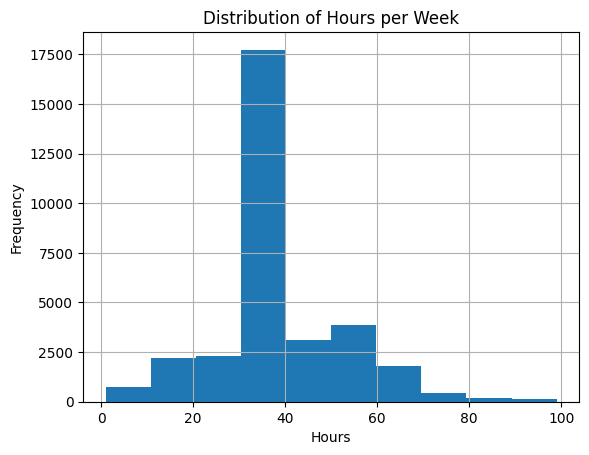

In [7]:
df['hours-per-week'].hist()
plt.title('Distribution of Hours per Week')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

### 6. (3đ) Tạo biểu đồ histogram của cột hours-per-week của những người cố số năm giáo dục (education-num) >= 9.

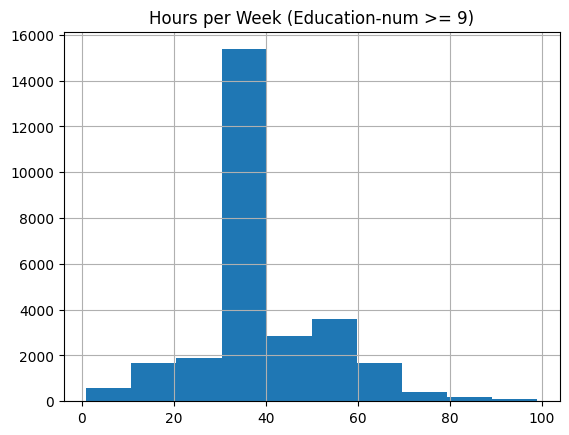

In [8]:
df[df['education-num'] >= 9]['hours-per-week'].hist()
plt.title('Hours per Week (Education-num >= 9)')
plt.show()

### 7. (3đ) Tạo pie chart thể hiện phần trăm của cột race và sex (sẽ có 5*2=10 categories tổng thể trong 1 hình vẽ). Nhận xét xem nhóm nào chiếm tỉ lệ nhiều nhất.

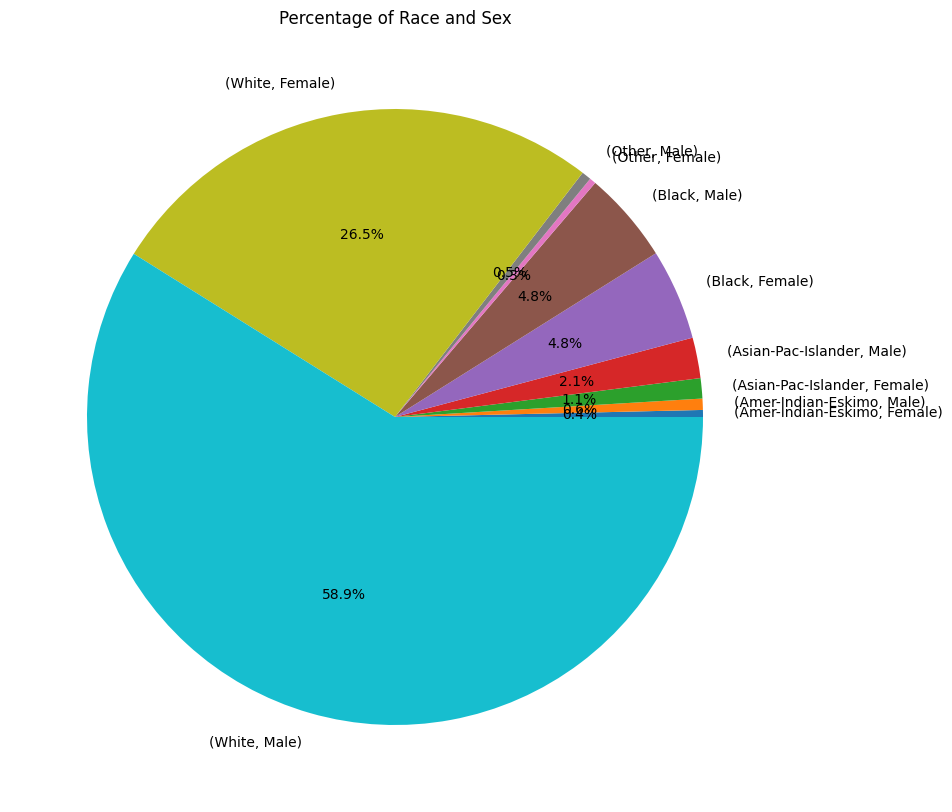

In [11]:
race_sex_counts = df.groupby(['race', 'sex']).size()
race_sex_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(10, 10))
plt.title('Percentage of Race and Sex')
plt.ylabel('')
plt.show()

### 8. (3đ) Tạo pie chart cho cột workclass và nhận xét xem nhóm nào chiếm nhiều nhất.

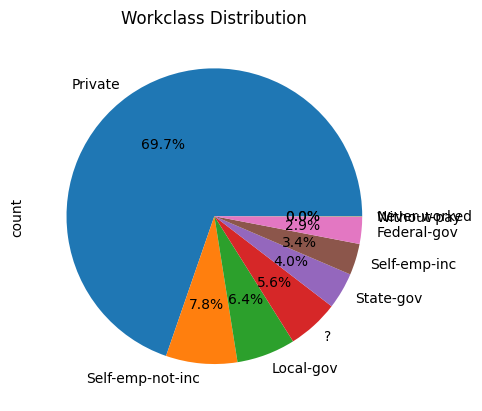

In [12]:
df['workclass'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Workclass Distribution')
plt.show()
#nhan xet : nhom "private" thuong chiem da so.

### 9. (3đ) Tạo scatter chart cho cột education-num và cột age.

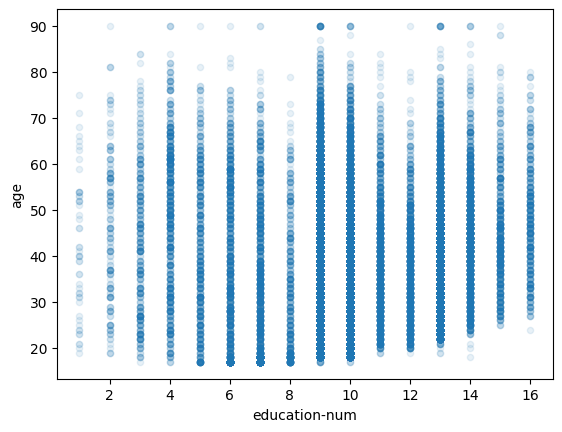

In [14]:
df.plot.scatter(x='education-num', y='age', alpha=0.1)
plt.show()

### 10. (3đ) Tạo scatter chart cho cột age và cột hours-per-week.

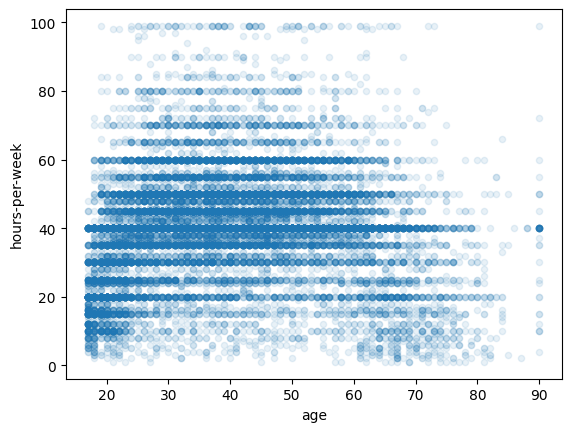

In [15]:
df.plot.scatter(x='age', y='hours-per-week', alpha=0.1)
plt.show()

### 11. (5đ) Tạo box plot cho cột race và cột education-num (Trục x là các categories của cột race, trục y là giá trị education-num).

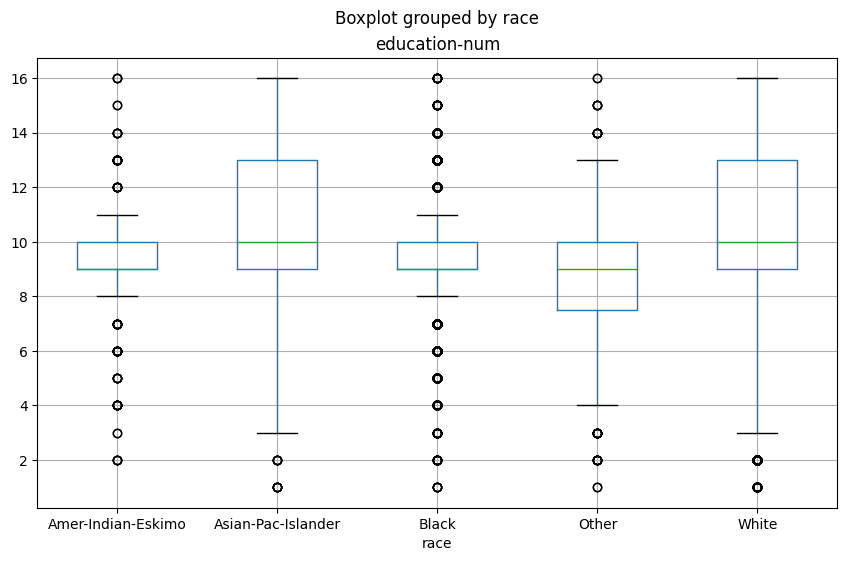

In [17]:
df.boxplot(column='education-num', by='race', figsize=(10,6))
plt.show()

### 12. (5đ) Tạo box plot cho cột workclass và cột hours-per-week (Trực x là các categories của cột workclass, trục y là giá trị hours-per-week).

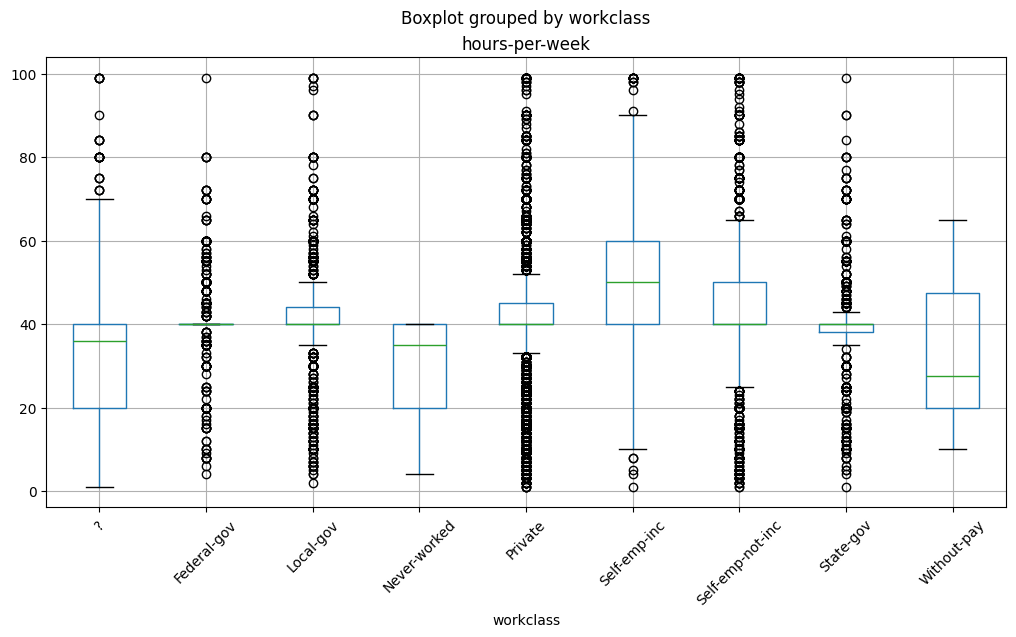

In [19]:
df.boxplot(column='hours-per-week', by='workclass', figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

### 13. (2đ) In ra 5 hàng cuối cùng của bảng dữ liệu

In [20]:
print(df.tail(5))

       age     workclass  fnlwgt   education  education-num  \
32556   27       Private  257302  Assoc-acdm             12   
32557   40       Private  154374     HS-grad              9   
32558   58       Private  151910     HS-grad              9   
32559   22       Private  201490     HS-grad              9   
32560   52  Self-emp-inc  287927     HS-grad              9   

           marital-status         occupation relationship   race     sex  \
32556  Married-civ-spouse       Tech-support         Wife  White  Female   
32557  Married-civ-spouse  Machine-op-inspct      Husband  White    Male   
32558             Widowed       Adm-clerical    Unmarried  White  Female   
32559       Never-married       Adm-clerical    Own-child  White    Male   
32560  Married-civ-spouse    Exec-managerial         Wife  White  Female   

       capital-gain  capital-loss  hours-per-week native-country salary  
32556             0             0              38  United-States  <=50K  
32557           

### 14. (3đ) Hiển thị các giá trị thống kê đối với các features dạng số và cho biết giá trị mean của capital-gain là bao nhiêu?

In [21]:
print(df.describe())
print("Mean cua capital-gain:", df['capital-gain'].mean())

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  
Mean cua capital-gain: 1077.6488437087312


### 15. (5đ) Độ tuổi trung bình của women là bao nhiêu?

In [22]:
tuoi_tb_nu = df[df['sex'] == 'Female']['age'].mean()
print(tuoi_tb_nu)


36.85823043357163


### 16. (5đ) Phần trăm dân số người German là bao nhiêu (native-country feature)?

In [23]:
phan_tram_duc = (df['native-country'] == 'Germany').mean() * 100
print(f"{phan_tram_duc}%")

0.42074874850281013%


### 17. (6đ) Độ lệch chuẩn và giá trị trung bình của độ tuổi đối với những người kiếm được hơn 50K mỗi năm (*native-country* feature) và những người kiếm được ít hơn 50K mỗi năm là bao nhiêu?

In [24]:
df.groupby('salary')['age'].agg(['mean', 'std'])

,mean,std
salary,,
<=50K,36.783738,14.020088
>50K,44.249841,10.519028


### 18. (6đ) Có đúng là những người kiếm được hơn 50K đều có trình độ học vấn ít nhất là  high school? (education feature – Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters or Doctorate)

In [25]:

hoc_cao = ['Bachelors', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Masters', 'Doctorate']
ngoai_le = df[(df['salary'] == '>50K') & (~df['education'].isin(hoc_cao))]
print("So nguoi luong cao nhung hoc van thap:", len(ngoai_le))

So nguoi luong cao nhung hoc van thap: 3306


### 19. (6đ) Hiển thị thống kê độ tuổi cho từng chủng tộc (race feature) và từng giới tính (sex feature). Sử dụng groupby() describe(). Tìm độ tuổi tối đa của nam giới thuộc chủng tộc Amer-Indian-Eskimo.

In [26]:

print(df.groupby(['race', 'sex'])['age'].describe())
max_age = df[(df['race'] == 'Amer-Indian-Eskimo') & (df['sex'] == 'Male')]['age'].max()
print("Tuổi max:", max_age)

                             count       mean        std   min   25%   50%  \
race               sex                                                       
Amer-Indian-Eskimo Female    119.0  37.117647  13.114991  17.0  27.0  36.0   
                   Male      192.0  37.208333  12.049563  17.0  28.0  35.0   
Asian-Pac-Islander Female    346.0  35.089595  12.300845  17.0  25.0  33.0   
                   Male      693.0  39.073593  12.883944  18.0  29.0  37.0   
Black              Female   1555.0  37.854019  12.637197  17.0  28.0  37.0   
                   Male     1569.0  37.682600  12.882612  17.0  27.0  36.0   
Other              Female    109.0  31.678899  11.631599  17.0  23.0  29.0   
                   Male      162.0  34.654321  11.355531  17.0  26.0  32.0   
White              Female   8642.0  36.811618  14.329093  17.0  25.0  35.0   
                   Male    19174.0  39.652498  13.436029  17.0  29.0  38.0   

                             75%   max  
race               sex

### 20. (6đ) Tỉ lệ người married hay single men (marital-status feature) chiếm nhiều hơn trong số những người kiếm được >50k? Những người có tình trạng hôn nhân (married) có marital-status feature bắt đầu với Married (Married-civ-spouse, Married-spouse-absent or Married-AF-spouse), còn lại được coi là single men.

In [ ]:
# You code here

### 21. (6đ) Số giờ tối đa một người làm việc mỗi tuần (hours-per-week feature) là bao nhiêu? Có bao nhiêu người làm việc với số giờ như vậy và tỷ lệ những người kiếm được nhiều (>50K) trong số đó là bao nhiêu?

In [ ]:
# You code here

### 22. (10đ) Tính thời gian làm việc trung bình (số giờ mỗi tuần) của những người kiếm được ít và nhiều (salary feature) cho mỗi quốc gia (native-country feature). Với đất nước Nhật Bản thì kết quả như nào?

In [ ]:
# You code here

### 23. (10đ) Số người da trắng (white in race feature) kiếm được số tiền >50k ở nước Mỹ chiếm bao nhiêu phần trăm. Câu hỏi tương tự với người da đen (black in race feature).

In [27]:

my_trang = df[(df['native-country'] == 'United-States') & (df['race'] == 'White')]
ty_le_my_trang_giau = (my_trang['salary'] == '>50K').mean() * 100
print(f"Da trang >50K ở My: {ty_le_my_trang_giau}%")

my_den = df[(df['native-country'] == 'United-States') & (df['race'] == 'Black')]
ty_le_my_den_giau = (my_den['salary'] == '>50K').mean() * 100
print(f"Da den >50K ở My: {ty_le_my_den_giau}%")

Da trang >50K ở My: 26.166035673861288%
Da den >50K ở My: 12.39406779661017%
